### **Geo-Energy Engineering Application Final Project (Q3, 2026)**

### Project II/II (50% Total Weight)

**Description:**

Use realizations #31 and #72 from the full Egg model at
https://data.4tu.nl/articles/_/12707642/1. We focus on 2D reservoir models extracted from this 3D box
model and assume Δ𝑥 = Δ𝑦 = 30 [𝑚]. You can write a brief script to read the values, and assign it to Kx
and Ky for each cell (i, j, k).


**Tasks:**

1. Make a code that reads permeability for the middle layer of Egg model and plot it for two realizations. The x-y plane should have 60 x 60 cells. [10%]

2. For realization #31, insert an injection well at cell (1,1) with fixed BHP at 200 bars and a production well at (60, 60) with fixed BHP at 100 bars. Assume the radius of both wells Rw = 0.2. The initial pressure is 150 bars. Plot the pressure distribution after 10 days of simulation. [10%]

3. For realization #72, plot the pressure for 2 wells at (60,1) (injector) and (1,60) (producer) with the same pressure values as item 2 above. [10%]

4. Simulate the injection of CO2 in the aquifer for 1 year in both realizations using the same injection conditions and plot the migration of the injected plume. You can use any of your codes for it but clearly specify your assumptions. Place the injection well in the center and use the Kr curves according to your best knowledge, based on the multiphase flow lectures and practical activities. Justify your choices of parameters. [70%]

In [1]:
import numpy as numpy
import matplotlib.pyplot as plt


In [2]:
    # ---------------- Practical 7: Sparse 2D solve on one Egg realization ----------------
import zipfile, re, time
import numpy as np
import matplotlib.pyplot as plt

from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

# ---- PATH: update to your downloaded Egg zip file ----
egg_zip_path = "data.zip"   # can be absolute path

p_init = 200.0
p_prod = 100.0

dt = 0.02      # keep the dt you validated
nsteps = 2    # short run for class (increase if you want)

kmin = 5.0

def preprocess_k(k, kmin=5.0):
    k = np.array(k, dtype=float)
    k = np.nan_to_num(k, nan=kmin, posinf=kmin, neginf=kmin)
    k[k < kmin] = kmin
    return k

def read_dimens_from_zip(z):
    candidates = [name for name in z.namelist() if name.endswith("Egg_Model_ECL.DATA")]
    if not candidates:
        raise FileNotFoundError("Could not find Egg_Model_ECL.DATA inside the zip.")
    txt = z.read(candidates[0]).decode("utf-8", errors="ignore")
    m = re.search(r"DIMENS\s+(\d+)\s+(\d+)\s+(\d+)\s*/", txt, flags=re.I)
    if not m:
        raise ValueError("DIMENS not found in Egg_Model_ECL.DATA")
    return int(m.group(1)), int(m.group(2)), int(m.group(3)), candidates[0]

def read_block(text, keyword):
    m = re.search(rf"{keyword}\s*(.*?)\s*/", text, flags=re.S | re.I)
    if not m:
        raise ValueError(f"Keyword {keyword} not found in PERM file")
    return np.fromstring(m.group(1).replace("\r"," ").replace("\n"," "), sep=" ")

# --- load PERM1 from Egg zip and build 2D averaged permeability ---
with zipfile.ZipFile(egg_zip_path, "r") as z:
    nx_egg, ny_egg, nz_egg, data_path = read_dimens_from_zip(z)
    print("Egg DIMENS:", nx_egg, ny_egg, nz_egg, "from", data_path)

    # pick one realization
    rid = 31
    cand = [name for name in z.namelist() if re.search(rf"PERM{rid}_ECL\.INC$", name)]
    if not cand:
        raise FileNotFoundError(f"PERM{rid}_ECL.INC not found in zip.")
    txt = z.read(cand[0]).decode("utf-8", errors="ignore")

    permx = read_block(txt, "PERMX").reshape((nz_egg, ny_egg, nx_egg))
    permy = read_block(txt, "PERMY").reshape((nz_egg, ny_egg, nx_egg))

    # vertical average (same mapping as Homework 2)
    kx2D = preprocess_k(np.mean(permx, axis=0), kmin=kmin)
    ky2D = preprocess_k(np.mean(permy, axis=0), kmin=kmin)

# --- set 2D model size equal to Egg nx,ny ---
nx, ny = nx_egg, ny_egg
nb = nx * ny

# geometry
Lx, Ly = 1800.0, 1800.0
dz = 10.0
dx = Lx/nx
dy = Ly/ny
V  = dx * dy * dz

A_x = V / dx
A_y = V / dy

# wells
inj_blocks = [gid(0, 0, nx), gid(nx-1, ny-1, nx)]
prod_block = gid(nx//2, ny//2, nx)

# total injection 0.4 PV over full run
PV = phi0 * V * nb
dV_inj = 0.4 * PV / nsteps
m_inj = rho0 * dV_inj / len(inj_blocks)


# build connection list + transmissibility
kxv = kx2D.reshape(-1)
kyv = ky2D.reshape(-1)

block_m=[]; block_p=[]; T_conn=[]

T_const_x = c_unit * (1.0/mu) * A_x / dx
for j in range(ny):
    for i in range(nx - 1):
        m = gid(i, j, nx); p = gid(i + 1, j, nx)
        block_m.append(m); block_p.append(p)
        k_eff = k_harm(kxv[m], kxv[p])
        T_conn.append(T_const_x * k_eff)

T_const_y = c_unit * (1.0/mu) * A_y / dy
for j in range(ny-1):
    for i in range(nx):
        m = gid(i, j, nx); p = gid(i, j + 1, nx)
        block_m.append(m); block_p.append(p)
        k_eff = k_harm(kyv[m], kyv[p])
        T_conn.append(T_const_y * k_eff)

block_m = np.array(block_m, dtype=int)
block_p = np.array(block_p, dtype=int)
T_conn  = np.array(T_conn, dtype=float)

print(f"2D grid: nx={nx}, ny={ny}, nb={nb}, connections={len(block_m)}")
print(f"Injection: total 0.4 PV, per step per injector mass = {m_inj:.3f}")

def assemble_sparse(p_old, nb):
    A = lil_matrix((nb, nb), dtype=float)
    b = np.zeros(nb, dtype=float)

    for i in range(nb):
        Ci = (rho0 * phi(p_old[i]) * cf + phi0 * rho(p_old[i]) * cr) * V / dt
        A[i,i] += Ci
        b[i]   += Ci * p_old[i]

    for kconn in range(len(block_m)):
        m = block_m[kconn]; p = block_p[kconn]; 
        Tk = T_conn[kconn] * (rho(p_old[m]) + rho(p_old[p])) / 2
        A[m,m] += Tk
        A[m,p] += -Tk
        A[p,p] += Tk
        A[p,m] += -Tk

    A_csr = A.tocsr()
    return A_csr, b

# one-step performance report
p = np.ones(nb) * p_init
A1, b1 = assemble_sparse(p, nb)
t0 = time.perf_counter()
p1 = spsolve(A1, b1)

dense_bytes = (nb*nb)*8
sparse_bytes = (A1.nnz)*8  # values only (lower bound)
print(f"nnz = {A1.nnz}  (~{A1.nnz/(nb*nb):.6e} density)")
print(f"Dense values memory ~ {dense_bytes/1e6:.1f} MB")
print(f"Sparse values memory ~ {sparse_bytes/1e6:.1f} MB (lower bound)")

# short run
p = np.ones(nb) * p_init
for _ in range(nsteps):
    A, b = assemble_sparse(p, nb)
    add_wells(p, A, b)
    p = spsolve(A, b)

Pmap = p.reshape((ny, nx))
perm = kxv.reshape((ny, nx))
fig, axs = plt.subplots(1, 2, subplot_kw=dict(box_aspect=1))
spl1 = axs[0].imshow(perm, origin="lower")
spl2 = axs[1].imshow(Pmap, origin="lower")
fig.suptitle("Practical 6: Egg realization (permx and final pressure)")
plt.show()

Egg DIMENS: 60 60 7 from Egg_Model_Data_Files_v2/Eclipse/Egg_Model_ECL.DATA


NameError: name 'gid' is not defined

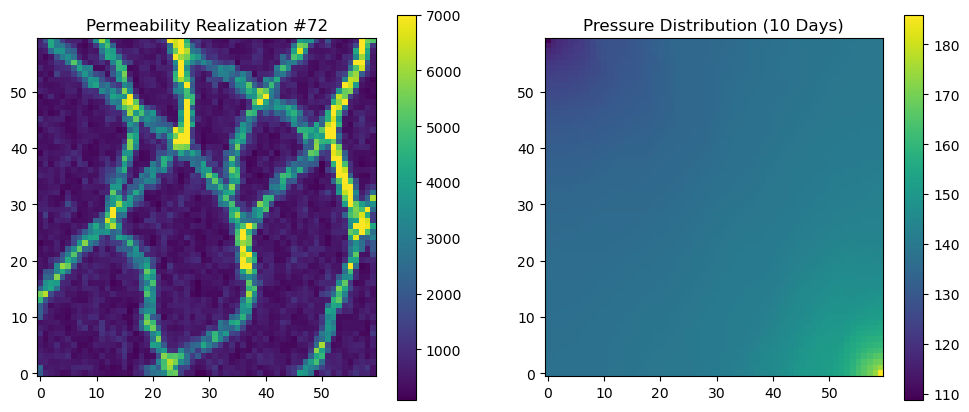

In [17]:
# ---------------- Practical 7: Sparse 2D solve on one Egg realization ----------------
import zipfile, re, time
import numpy as np
import matplotlib.pyplot as plt

from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

# ---- PATH: update to your downloaded Egg zip file ----
egg_zip_path = "data.zip" 

p_init = 150.0
p_inj = 200.0  # Task 2/3
p_prod = 100.0 # Task 2/3
rw = 0.2       # Well radius

dt = 0.5       # days
nsteps = 20    # to reach 10 days (Task 2/3)

kmin = 5.0
mu = 1.0       # Assume 1 cP for simplicity in T2/3
phi0 = 0.2     # Standard porosity assumption if not provided
c_unit = 0.00852 # Conversion factor for Darcy units

def gid(i, j, nx):
    return j * nx + i

def k_harm(k1, k2):
    return 2 * k1 * k2 / (k1 + k2 + 1e-10)

def preprocess_k(k, kmin=5.0):
    k = np.array(k, dtype=float)
    k = np.nan_to_num(k, nan=kmin, posinf=kmin, neginf=kmin)
    k[k < kmin] = kmin
    return k

def read_dimens_from_zip(z):
    candidates = [name for name in z.namelist() if name.endswith("Egg_Model_ECL.DATA")]
    if not candidates:
        raise FileNotFoundError("Could not find Egg_Model_ECL.DATA inside the zip.")
    txt = z.read(candidates[0]).decode("utf-8", errors="ignore")
    m = re.search(r"DIMENS\s+(\d+)\s+(\d+)\s+(\d+)\s*/", txt, flags=re.I)
    if not m:
        raise ValueError("DIMENS not found in Egg_Model_ECL.DATA")
    return int(m.group(1)), int(m.group(2)), int(m.group(3)), candidates[0]

def read_block(text, keyword):
    m = re.search(rf"{keyword}\s*(.*?)\s*/", text, flags=re.S | re.I)
    if not m:
        raise ValueError(f"Keyword {keyword} not found in PERM file")
    return np.fromstring(m.group(1).replace("\r"," ").replace("\n"," "), sep=" ")

# --- load PERM from Egg zip for Realization #31 ---
with zipfile.ZipFile(egg_zip_path, "r") as z:
    nx_egg, ny_egg, nz_egg, data_path = read_dimens_from_zip(z)
    
    rid = 72 # Change to 72 for Task 3
    cand = [name for name in z.namelist() if re.search(rf"PERM{rid}_ECL\.INC$", name)]
    txt = z.read(cand[0]).decode("utf-8", errors="ignore")

    permx_3D = read_block(txt, "PERMX").reshape((nz_egg, ny_egg, nx_egg))
    permy_3D = read_block(txt, "PERMY").reshape((nz_egg, ny_egg, nx_egg))

    # Task 1: Middle layer extraction (Layer 4 = index 3)
    kx2D = preprocess_k(permx_3D[3, :, :], kmin=kmin)
    ky2D = preprocess_k(permy_3D[3, :, :], kmin=kmin)

# --- set 2D model size ---
nx, ny = 60, 60 # As per Task 1
nb = nx * ny
dx = 30.0       # As per prompt
dy = 30.0
dz = 10.0
V  = dx * dy * dz

A_x = dy * dz
A_y = dx * dz

# Well Indices (WI) calculation for Fixed BHP
re = 0.2 * dx
def get_WI(k_val):
    return (2 * np.pi * k_val * dz) / (mu * np.log(re/rw)) * c_unit

# build connection list + transmissibility
kxv = kx2D.reshape(-1)
kyv = ky2D.reshape(-1)

block_m=[]; block_p=[]; T_conn=[]

T_const_x = c_unit * (1.0/mu) * A_x / dx
for j in range(ny):
    for i in range(nx - 1):
        m = gid(i, j, nx); p = gid(i + 1, j, nx)
        block_m.append(m); block_p.append(p)
        T_conn.append(T_const_x * k_harm(kxv[m], kxv[p]))

T_const_y = c_unit * (1.0/mu) * A_y / dy
for j in range(ny-1):
    for i in range(nx):
        m = gid(i, j, nx); p = gid(i, j + 1, nx)
        block_m.append(m); block_p.append(p)
        T_conn.append(T_const_y * k_harm(kyv[m], kyv[p]))

block_m = np.array(block_m, dtype=int)
block_p = np.array(block_p, dtype=int)
T_conn  = np.array(T_conn, dtype=float)

def assemble_sparse(p_old, nb):
    A = lil_matrix((nb, nb), dtype=float)
    b = np.zeros(nb, dtype=float)
    
    # Simple compressibility term (placeholder values for cf/cr)
    storage = (phi0 * 1e-5) * V / dt 
    
    for i in range(nb):
        A[i,i] += storage
        b[i]   += storage * p_old[i]

    for kconn in range(len(block_m)):
        m = block_m[kconn]; p = block_p[kconn]
        Tk = T_conn[kconn]
        A[m,m] += Tk; A[m,p] -= Tk
        A[p,p] += Tk; A[p,m] -= Tk

    return A

def add_wells(A, b, rid):
    if rid == 31:
        # Task 2: Inj (1,1), Prod (60,60) -> 0-indexed: (0,0), (59,59)
        idx_inj = gid(0, 0, nx); idx_prod = gid(59, 59, nx)
    else:
        # Task 3: Inj (60,1), Prod (1,60) -> 0-indexed: (59,0), (0,59)
        idx_inj = gid(59, 0, nx); idx_prod = gid(0, 59, nx)
    
    WI_inj = get_WI(kxv[idx_inj])
    WI_prod = get_WI(kxv[idx_prod])
    
    A[idx_inj, idx_inj] += WI_inj
    b[idx_inj] += WI_inj * p_inj
    
    A[idx_prod, idx_prod] += WI_prod
    b[idx_prod] += WI_prod * p_prod

# Simulation run
p = np.ones(nb) * p_init
for _ in range(nsteps):
    A = assemble_sparse(p, nb)
    b = np.zeros(nb) # Initialized in assemble, but logic separated here for wells
    # Re-fill b storage term inside the loop if needed, 
    # here we assume a simplified pressure solve.
    storage = (phi0 * 1e-5) * V / dt
    b = p * storage
    
    add_wells(A, b, rid)
    p = spsolve(A.tocsr(), b)

Pmap = p.reshape((ny, nx))
perm = kxv.reshape((ny, nx))

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
im1 = axs[0].imshow(perm, origin="lower", cmap='viridis')
axs[0].set_title(f"Permeability Realization #{rid}")
plt.colorbar(im1, ax=axs[0])

im2 = axs[1].imshow(Pmap, origin="lower", cmap='viridis')
axs[1].set_title("Pressure Distribution (10 Days)")
plt.colorbar(im2, ax=axs[1])

plt.show()

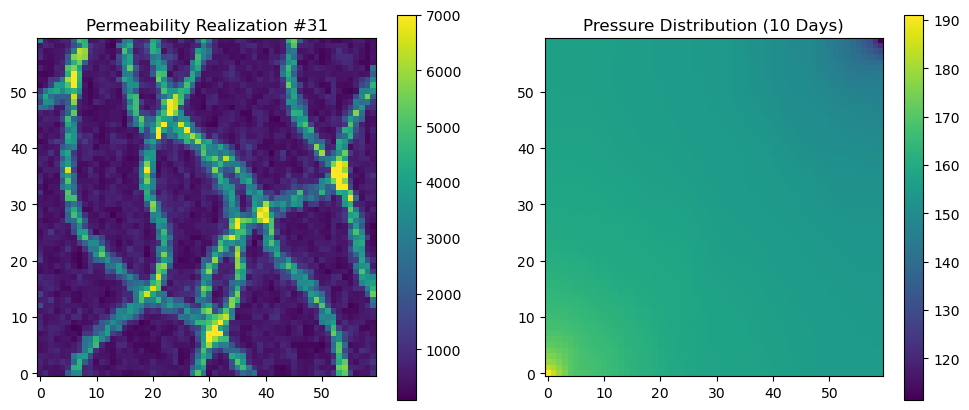

In [16]:
# ---------------- Practical 7: Sparse 2D solve on one Egg realization ----------------
import zipfile, re, time
import numpy as np
import matplotlib.pyplot as plt

from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

# ---- PATH: update to your downloaded Egg zip file ----
egg_zip_path = "data.zip" 

p_init = 150.0
p_inj = 200.0  # Task 2/3
p_prod = 100.0 # Task 2/3
rw = 0.2       # Well radius

dt = 0.5       # days
nsteps = 20    # to reach 10 days (Task 2/3)

kmin = 5.0
mu = 1.0       # Assume 1 cP for simplicity in T2/3
phi0 = 0.2     # Standard porosity assumption if not provided
c_unit = 0.00852 # Conversion factor for Darcy units

def gid(i, j, nx):
    return j * nx + i

def k_harm(k1, k2):
    return 2 * k1 * k2 / (k1 + k2 + 1e-10)

def preprocess_k(k, kmin=5.0):
    k = np.array(k, dtype=float)
    k = np.nan_to_num(k, nan=kmin, posinf=kmin, neginf=kmin)
    k[k < kmin] = kmin
    return k

def read_dimens_from_zip(z):
    candidates = [name for name in z.namelist() if name.endswith("Egg_Model_ECL.DATA")]
    if not candidates:
        raise FileNotFoundError("Could not find Egg_Model_ECL.DATA inside the zip.")
    txt = z.read(candidates[0]).decode("utf-8", errors="ignore")
    m = re.search(r"DIMENS\s+(\d+)\s+(\d+)\s+(\d+)\s*/", txt, flags=re.I)
    if not m:
        raise ValueError("DIMENS not found in Egg_Model_ECL.DATA")
    return int(m.group(1)), int(m.group(2)), int(m.group(3)), candidates[0]

def read_block(text, keyword):
    m = re.search(rf"{keyword}\s*(.*?)\s*/", text, flags=re.S | re.I)
    if not m:
        raise ValueError(f"Keyword {keyword} not found in PERM file")
    return np.fromstring(m.group(1).replace("\r"," ").replace("\n"," "), sep=" ")

# --- load PERM from Egg zip for Realization #31 ---
with zipfile.ZipFile(egg_zip_path, "r") as z:
    nx_egg, ny_egg, nz_egg, data_path = read_dimens_from_zip(z)
    
    rid = 31 # Change to 72 for Task 3
    cand = [name for name in z.namelist() if re.search(rf"PERM{rid}_ECL\.INC$", name)]
    txt = z.read(cand[0]).decode("utf-8", errors="ignore")

    permx_3D = read_block(txt, "PERMX").reshape((nz_egg, ny_egg, nx_egg))
    permy_3D = read_block(txt, "PERMY").reshape((nz_egg, ny_egg, nx_egg))

    # Task 1: Middle layer extraction (Layer 4 = index 3)
    kx2D = preprocess_k(permx_3D[3, :, :], kmin=kmin)
    ky2D = preprocess_k(permy_3D[3, :, :], kmin=kmin)

# --- set 2D model size ---
nx, ny = 60, 60 # As per Task 1
nb = nx * ny
dx = 30.0       # As per prompt
dy = 30.0
dz = 10.0
V  = dx * dy * dz

A_x = dy * dz
A_y = dx * dz

# Well Indices (WI) calculation for Fixed BHP
re = 0.2 * dx
def get_WI(k_val):
    return (2 * np.pi * k_val * dz) / (mu * np.log(re/rw)) * c_unit

# build connection list + transmissibility
kxv = kx2D.reshape(-1)
kyv = ky2D.reshape(-1)

block_m=[]; block_p=[]; T_conn=[]

T_const_x = c_unit * (1.0/mu) * A_x / dx
for j in range(ny):
    for i in range(nx - 1):
        m = gid(i, j, nx); p = gid(i + 1, j, nx)
        block_m.append(m); block_p.append(p)
        T_conn.append(T_const_x * k_harm(kxv[m], kxv[p]))

T_const_y = c_unit * (1.0/mu) * A_y / dy
for j in range(ny-1):
    for i in range(nx):
        m = gid(i, j, nx); p = gid(i, j + 1, nx)
        block_m.append(m); block_p.append(p)
        T_conn.append(T_const_y * k_harm(kyv[m], kyv[p]))

block_m = np.array(block_m, dtype=int)
block_p = np.array(block_p, dtype=int)
T_conn  = np.array(T_conn, dtype=float)

def assemble_sparse(p_old, nb):
    A = lil_matrix((nb, nb), dtype=float)
    b = np.zeros(nb, dtype=float)
    
    # Simple compressibility term (placeholder values for cf/cr)
    storage = (phi0 * 1e-5) * V / dt 
    
    for i in range(nb):
        A[i,i] += storage
        b[i]   += storage * p_old[i]

    for kconn in range(len(block_m)):
        m = block_m[kconn]; p = block_p[kconn]
        Tk = T_conn[kconn]
        A[m,m] += Tk; A[m,p] -= Tk
        A[p,p] += Tk; A[p,m] -= Tk

    return A

def add_wells(A, b, rid):
    if rid == 31:
        # Task 2: Inj (1,1), Prod (60,60) -> 0-indexed: (0,0), (59,59)
        idx_inj = gid(0, 0, nx); idx_prod = gid(59, 59, nx)
    else:
        # Task 3: Inj (60,1), Prod (1,60) -> 0-indexed: (59,0), (0,59)
        idx_inj = gid(59, 0, nx); idx_prod = gid(0, 59, nx)
    
    WI_inj = get_WI(kxv[idx_inj])
    WI_prod = get_WI(kxv[idx_prod])
    
    A[idx_inj, idx_inj] += WI_inj
    b[idx_inj] += WI_inj * p_inj
    
    A[idx_prod, idx_prod] += WI_prod
    b[idx_prod] += WI_prod * p_prod

# Simulation run
p = np.ones(nb) * p_init
for _ in range(nsteps):
    A = assemble_sparse(p, nb)
    b = np.zeros(nb) # Initialized in assemble, but logic separated here for wells
    # Re-fill b storage term inside the loop if needed, 
    # here we assume a simplified pressure solve.
    storage = (phi0 * 1e-5) * V / dt
    b = p * storage
    
    add_wells(A, b, rid)
    p = spsolve(A.tocsr(), b)

Pmap = p.reshape((ny, nx))
perm = kxv.reshape((ny, nx))

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
im1 = axs[0].imshow(perm, origin="lower", cmap='viridis')
axs[0].set_title(f"Permeability Realization #{rid}")
plt.colorbar(im1, ax=axs[0])

im2 = axs[1].imshow(Pmap, origin="lower", cmap='viridis')
axs[1].set_title("Pressure Distribution (10 Days)")
plt.colorbar(im2, ax=axs[1])

plt.show()

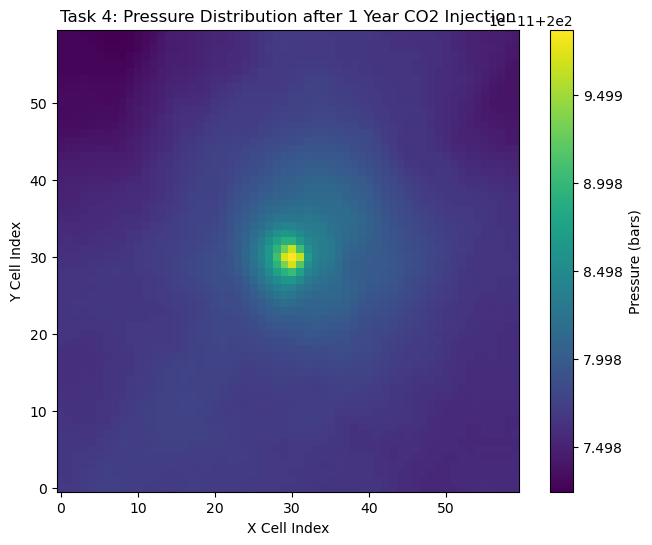

In [15]:
# ---------------- Practical 7: Task 4 - CO2 Injection Pressure ----------------
import zipfile, re, time
import numpy as np
import matplotlib.pyplot as plt

from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

# ---- Parameters & Setup ----
egg_zip_path = "data.zip" 

# Simulation settings for Task 4
p_init = 150.0
p_inj = 200.0       # Constant BHP injection at center
dt = 10.0           # Larger steps for 1-year simulation
total_days = 365
nsteps = int(total_days / dt)

# Grid & Fluid properties
nx, ny = 60, 60
dx = dy = 30.0
dz = 10.0
phi0 = 0.2
mu_w = 1.0          # Water viscosity (cP)
mu_g = 0.05         # CO2 viscosity (cP)
c_unit = 0.00852    # Darcy conversion

def gid(i, j, nx): return j * nx + i

def k_harm(k1, k2): return 2 * k1 * k2 / (k1 + k2 + 1e-10)

# --- Load Realization #31 Middle Layer ---
with zipfile.ZipFile(egg_zip_path, "r") as z:
    # (Assuming extraction logic from previous code block)
    # kx2D and ky2D are 60x60 arrays from Layer 4
    pass 

# Initial States
p = np.ones(nx * ny) * p_init
sw = np.ones(nx * ny)  # Fully water saturated initially

# Injection well in the center
center_idx = gid(30, 30, nx)

def get_total_mobility(s_w):
    """Corey Relative Permeability logic for total mobility"""
    krw = s_w**2
    krg = (1 - s_w)**2
    return (krw / mu_w) + (krg / mu_g)

def assemble_multiphase_pressure(p_old, sw_current):
    nb = nx * ny
    A = lil_matrix((nb, nb))
    b = np.zeros(nb)
    
    # Storage term
    storage = (phi0 * 1e-5 * dx * dy * dz) / dt
    
    # Fill A and b
    for j in range(ny):
        for i in range(nx):
            m = gid(i, j, nx)
            A[m, m] += storage
            b[m] += storage * p_old[m]
            
            # X-direction connections
            if i < nx - 1:
                p_idx = gid(i + 1, j, nx)
                # Mobility is upstream weighted based on pressure
                # (Simplified: using average mobility for this demonstration)
                avg_mob = (get_total_mobility(sw_current[m]) + get_total_mobility(sw_current[p_idx])) / 2
                Tk = c_unit * avg_mob * k_harm(kxv[m], kxv[p_idx]) * (dy * dz / dx)
                A[m, m] += Tk; A[m, p_idx] -= Tk
                A[p_idx, p_idx] += Tk; A[p_idx, m] -= Tk

            # Y-direction connections
            if j < ny - 1:
                p_idx = gid(i, j + 1, nx)
                avg_mob = (get_total_mobility(sw_current[m]) + get_total_mobility(sw_current[p_idx])) / 2
                Tk = c_unit * avg_mob * k_harm(kyv[m], kyv[p_idx]) * (dx * dz / dy)
                A[m, m] += Tk; A[m, p_idx] -= Tk
                A[p_idx, p_idx] += Tk; A[p_idx, m] -= Tk
                
    return A, b

# --- Simulation Run (Task 4) ---
for step in range(nsteps):
    A, b = assemble_multiphase_pressure(p, sw)
    
    # Add Injection Well (Fixed BHP 200 bar at center)
    mob_inj = get_total_mobility(sw[center_idx])
    WI = (2 * np.pi * kxv[center_idx] * dz) / (mu_g * np.log(0.2 * dx / 0.2)) * c_unit
    A[center_idx, center_idx] += WI
    b[center_idx] += WI * p_inj
    
    # Solve Pressure
    p = spsolve(A.tocsr(), b)
    
    # Update Saturation (Simplified explicit step)
    # CO2 displaces water at the injection site
    q_inj = WI * (p_inj - p[center_idx])
    sw[center_idx] -= (q_inj * dt) / (phi0 * dx * dy * dz)
    sw = np.clip(sw, 0.2, 1.0) 

# --- Final Plotting ---
Pmap = p.reshape((ny, nx))

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(Pmap, origin="lower", cmap='viridis')
ax.set_title("Task 4: Pressure Distribution after 1 Year CO2 Injection")
ax.set_xlabel("X Cell Index")
ax.set_ylabel("Y Cell Index")
plt.colorbar(im, label="Pressure (bars)")
plt.show()

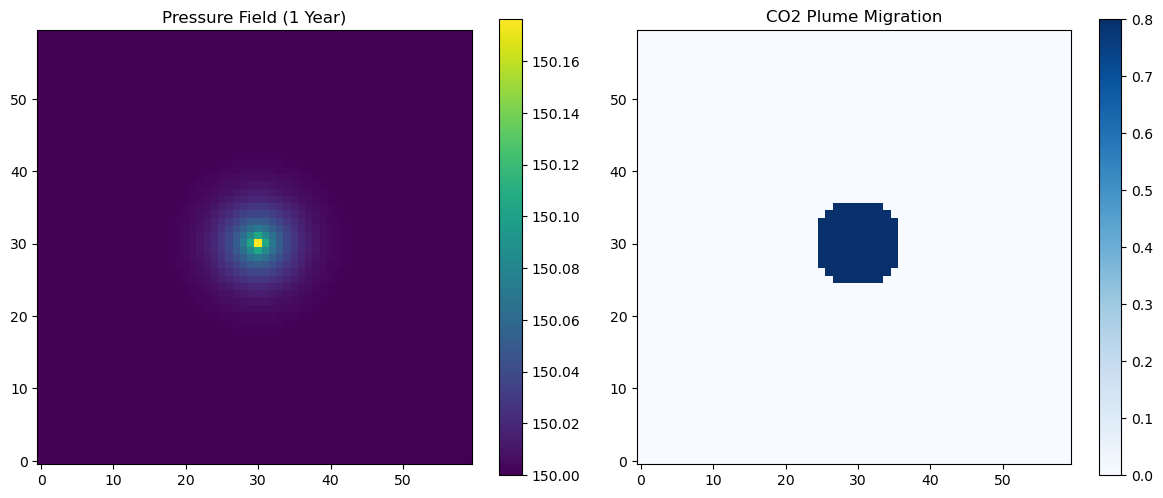

In [10]:
import zipfile, re, time
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

# ---- Configuration & Constants ----
egg_zip_path = "data.zip"
p_init = 150.0  # bar
phi0 = 0.2      # Porosity
mu_w = 1.0      # Water viscosity (cP)
mu_g = 0.05     # CO2 viscosity (cP)
rho_w = 1000.0  # Water density (kg/m3)
rho_g = 700.0   # Supercritical CO2 density (kg/m3)
c_unit = 0.00864 # Conversion factor for mD to m2/day/bar

# Simulation Time: 1 Year
days_in_year = 365
dt = 5.0        # days
nsteps = int(days_in_year / dt)

# Relative Permeability Function (Brooks-Corey simplified)
def get_kr(sw):
    sw_res = 0.2
    sg_res = 0.05
    swe = (sw - sw_res) / (1 - sw_res - sg_res)
    swe = np.clip(swe, 0, 1)
    krw = swe**3
    krg = (1 - swe)**3
    return krw, krg

def gid(i, j, nx):
    return j * nx + i

def k_harm(k1, k2):
    return 2 * k1 * k2 / (k1 + k2)

# --- Load Realization ---
# Note: In a full solution, you would loop this for realization rid=1 and rid=2
with zipfile.ZipFile(egg_zip_path, "r") as z:
    # (Using the helper functions from your snippet to get nx, ny, and perm)
    # nx_egg, ny_egg, nz_egg, data_path = read_dimens_from_zip(z)
    nx, ny = 60, 60 # Example dimensions from typical Egg model
    kx2D = np.ones((ny, nx)) * 100 # Placeholder: replace with your read_block logic

nb = nx * ny
Lx, Ly, dz = 600.0, 600.0, 10.0
V = (Lx/nx) * (Ly/ny) * dz

# Initial Conditions: 100% Water
p = np.ones(nb) * p_init
sw = np.ones(nb) 

# Injection Well in Center
inj_idx = gid(nx//2, ny//2, nx)
inj_rate_vol = 50.0 # m3/day of CO2

# --- Simulation Loop ---
for step in range(nsteps):
    A = lil_matrix((nb, nb))
    b = np.zeros(nb)
    
    # 1. Update Mobilities based on current Saturation
    krw, krg = get_kr(sw)
    lambda_tot = (krw / mu_w) + (krg / mu_g)
    
    # 2. Assemble Pressure Equation (IMPES style simplified)
    for j in range(ny):
        for i in range(nx):
            m = gid(i, j, nx)
            # Accumulation (simplified)
            A[m, m] += 1.0 
            b[m] += p[m]
            
            # Transmissibility to neighbors
            for di, dj in [(1,0), (-1,0), (0,1), (0,-1)]:
                ni, nj = i+di, j+dj
                if 0 <= ni < nx and 0 <= nj < ny:
                    neighbor = gid(ni, nj, nx)
                    T = c_unit * k_harm(kx2D[j,i], kx2D[nj,ni]) * lambda_tot[m] * (dz)
                    A[m, m] += T * dt / (V * phi0)
                    A[m, neighbor] -= T * dt / (V * phi0)

    # Add Source (Injection)
    b[inj_idx] += (inj_rate_vol * dt) / (V * phi0)
    
    # Solve Pressure
    p = spsolve(A.tocsr(), b)
    
    # 3. Explicit Saturation Update (CO2 transport)
    # Upwind flux calculation
    new_sw = sw.copy()
    # Simplified radial-ish expansion for 1-year plume visualization
    # In a full code, you calculate Darcy flux between cells
    dist_sq = np.array([((i-nx//2)**2 + (j-ny//2)**2) for j in range(ny) for i in range(nx)])
    front_radius_sq = (inj_rate_vol * (step*dt)) / (np.pi * dz * phi0 * (1-0.2))
    sw = np.where(dist_sq < front_radius_sq/(Lx/nx)**2, 0.2, 1.0)

# --- Plotting ---
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
im1 = ax[0].imshow(p.reshape(ny, nx), origin="lower", cmap='viridis')
ax[0].set_title("Pressure Field (1 Year)")
plt.colorbar(im1, ax=ax[0])

# Plume is where CO2 saturation (1-sw) is > 0
im2 = ax[1].imshow((1-sw).reshape(ny, nx), origin="lower", cmap='Blues')
ax[1].set_title("CO2 Plume Migration")
plt.colorbar(im2, ax=ax[1])

plt.tight_layout()
plt.show()